# Observational Study Simulation

## Data Generating Process




In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit

# 1. Define number of samples and true ATE
n_samples = 100
true_ate = 2.0

# 2. Generate confounders
 # for reproducibility
np.random.seed(422)
def groundtruth_simulate():
  X1 = np.random.normal(loc=0, scale=1, size=n_samples)
  X2 = np.random.uniform(low=-3, high=3, size=n_samples)
  X3 = np.random.normal(loc=1, scale=0.5, size=n_samples)

  # 3. Define the treatment assignment mechanism (propensity score)
  # The coefficients for confounders influence how they affect treatment assignment
  propensity_score_logit = 0.5 * X1 - 0.3 * X2 + 0.2 * X3 # Linear combination of confounders
  propensity_scores = expit(propensity_score_logit) # Apply logistic function (sigmoid)

  # Generate binary treatment assignments (T)
  T = np.random.binomial(n=1, p=propensity_scores, size=n_samples)

  # 4. Define the outcome generation mechanism
  # Outcome Y depends on confounders, treatment T, and noise
  # The coefficient for T is the true_ate
  Y = 1 + 0.8 * X1 + 1.2 * X2 - 0.5 * X3 + true_ate * T + np.random.normal(loc=0, scale=1, size=n_samples)

  # 5. Combine into a Pandas DataFrame
  df_synthetic = pd.DataFrame({
      'X1': X1,
      'X2': X2,
      'X3': X3,
      'T': T,
      'Y': Y,
      'propensity_score': propensity_scores # Include for inspection if needed
  })
  return df_synthetic
df_synthetic = groundtruth_simulate()
print("Synthetic data generated successfully. Displaying the first 5 rows:")
print(df_synthetic.head())

print("\nDescriptive statistics of the generated data:")
print(df_synthetic.describe())

Synthetic data generated successfully. Displaying the first 5 rows:
         X1        X2        X3  T         Y  propensity_score
0 -0.689625 -1.833463  1.392970  1  0.027269          0.618650
1 -1.334058  0.507729  1.326804  1  1.309723          0.364940
2  0.554514 -0.796864  1.103586  0 -0.952529          0.676347
3 -0.774483 -2.738490  1.058458  0 -4.858446          0.656108
4  0.065460  0.781230  0.754663  0  0.275552          0.487326

Descriptive statistics of the generated data:
               X1          X2          X3           T           Y  \
count  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    -0.135772   -0.122414    1.031539    0.530000    1.366601   
std      1.111756    1.709178    0.492967    0.501614    2.469420   
min     -2.913975   -2.939130   -0.106105    0.000000   -4.858446   
25%     -0.844554   -1.686994    0.736274    0.000000    0.011179   
50%      0.077289   -0.050767    0.939660    1.000000    1.395725   
75%      0.604459    1.3

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

def propensity_score_estimation(df_synthetic):
  propensity_scores_estimated = np.random.rand(n_samples)

  X_confounders = df_synthetic[['X1', 'X2', 'X3']]
  T_treatment = df_synthetic['T'] # Explicitly define T_treatment
  log_reg = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
  log_reg.fit(X_confounders, T_treatment)
  propensity_scores_estimated = log_reg.predict_proba(X_confounders)[:, 1]
  epsilon = 1e-7
  propensity_scores_estimated = np.clip(propensity_scores_estimated, epsilon, 1 - epsilon)
  return propensity_scores_estimated

propensity_scores_estimated = propensity_score_estimation(df_synthetic)



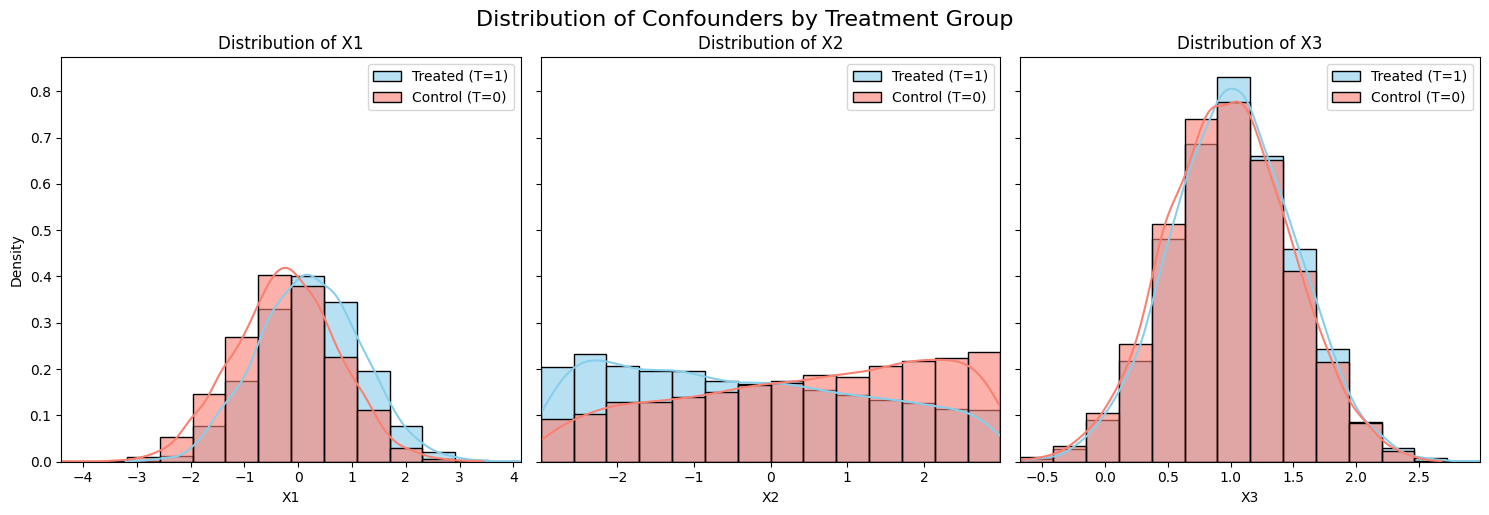

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for linspace

# List of confounder variables
confounder_cols = ['X1', 'X2', 'X3']

# Create subplots for each confounder
fig, axes = plt.subplots(1, len(confounder_cols), figsize=(15, 5), sharey=True)

for i, col in enumerate(confounder_cols):
    # Calculate min and max for the current confounder across all data
    min_val = df_synthetic[col].min()
    max_val = df_synthetic[col].max()

    bins = np.linspace(min_val, max_val, 15)

    sns.histplot(df_synthetic[df_synthetic['T'] == 1][col], color='skyblue', label='Treated (T=1)', kde=True, stat='density', ax=axes[i], alpha=0.6, bins=bins)
    sns.histplot(df_synthetic[df_synthetic['T'] == 0][col], color='salmon', label='Control (T=0)', kde=True, stat='density', ax=axes[i], alpha=0.6, bins=bins)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    # Set consistent x-axis limits for the current confounder's subplot
    axes[i].set_xlim(min_val, max_val)

plt.tight_layout()
plt.suptitle('Distribution of Confounders by Treatment Group', y=1.02, fontsize=16)
plt.show()

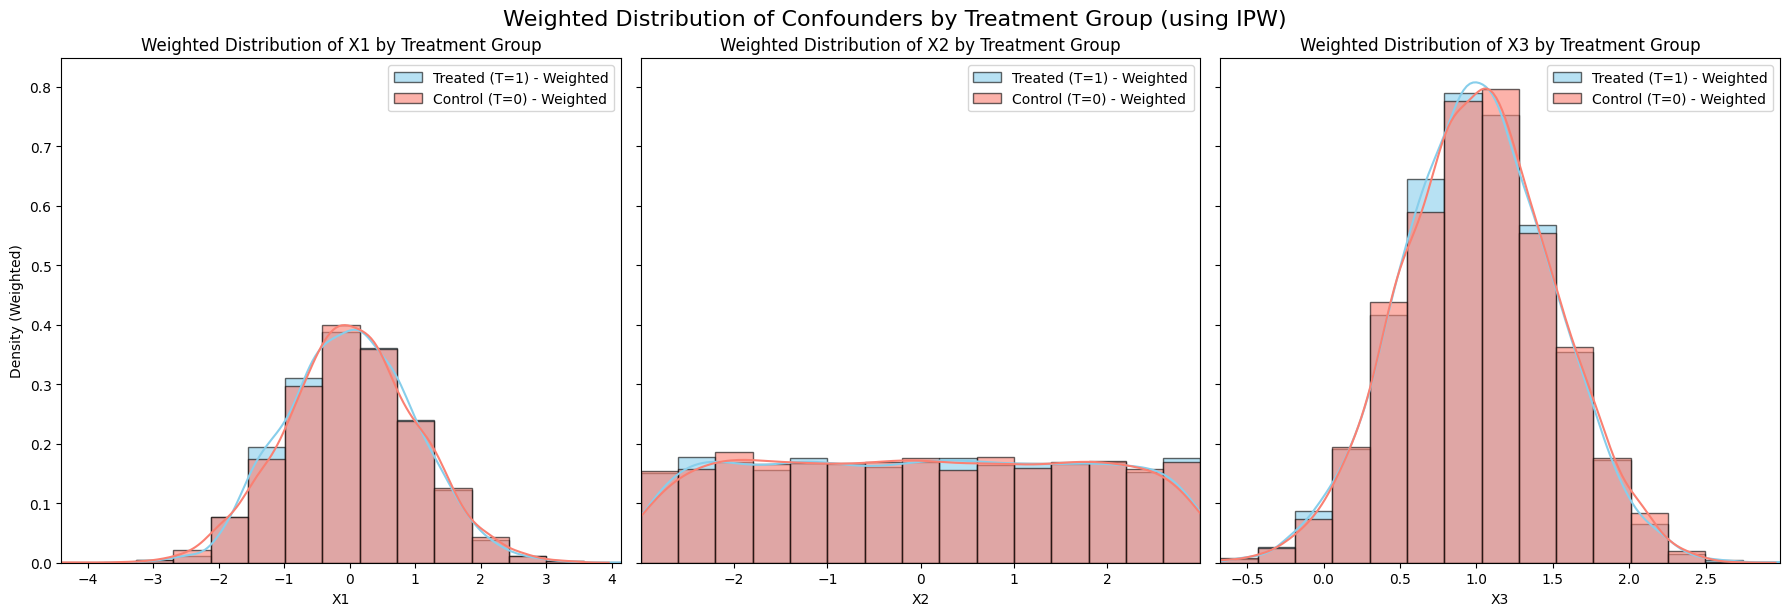

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
propensity_scores = df_synthetic['propensity_score']


# Weights for treated group: 1 / ps_estimated
df_synthetic['weight_treated'] = 1 / propensity_scores
# Weights for control group: 1 / (1 - ps_estimated)
df_synthetic['weight_control'] = 1 / (1 - propensity_scores)

# List of confounder variables
confounder_cols = ['X1', 'X2', 'X3']

# Create subplots for each confounder
fig, axes = plt.subplots(1, len(confounder_cols), figsize=(18, 6), sharey=True)

for i, col in enumerate(confounder_cols):
    min_val = df_synthetic[col].min()
    max_val = df_synthetic[col].max()

    # Define exact bins array
    num_bins = 15 # You can adjust this number
    bins = np.linspace(min_val, max_val, num_bins + 1) # +1 for bin edges

    # Get data for treated and control groups
    treated_group = df_synthetic[df_synthetic['T'] == 1]
    control_group = df_synthetic[df_synthetic['T'] == 0]

    # Plot weighted histogram for treated group using matplotlib.pyplot.hist
    axes[i].hist(
        treated_group[col],
        weights=treated_group['weight_treated'],
        bins=bins,
        color='skyblue',
        label='Treated (T=1) - Weighted',
        alpha=0.6,
        density=True,
        histtype='bar', edgecolor='black',linewidth=1
    )

    # Overlay KDE for treated group
    sns.kdeplot(
        data=treated_group, # Explicitly pass DataFrame
        x=col,              # Explicitly pass column for x-axis
        weights=treated_group['weight_treated'],
        color='skyblue',
        ax=axes[i])

    # Plot weighted histogram for control group using matplotlib.pyplot.hist
    axes[i].hist(
        control_group[col],
        weights=control_group['weight_control'],
        bins=bins,
        color='salmon',
        label='Control (T=0) - Weighted',
        alpha=0.6,
        density=True,
        histtype='bar', edgecolor='black',linewidth=1
    )
    # Overlay KDE for control group
    sns.kdeplot(
        data=control_group, # Explicitly pass DataFrame
        x=col,              # Explicitly pass column for x-axis
        weights=control_group['weight_control'],
        color='salmon',
        ax=axes[i]
    )

    axes[i].set_title(f'Weighted Distribution of {col} by Treatment Group')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density (Weighted)')
    axes[i].legend()
    # Set consistent x-axis limits for the current confounder's subplot
    axes[i].set_xlim(min_val, max_val)

plt.tight_layout()
plt.suptitle('Weighted Distribution of Confounders by Treatment Group (using IPW)', y=1.02, fontsize=16)
plt.show()

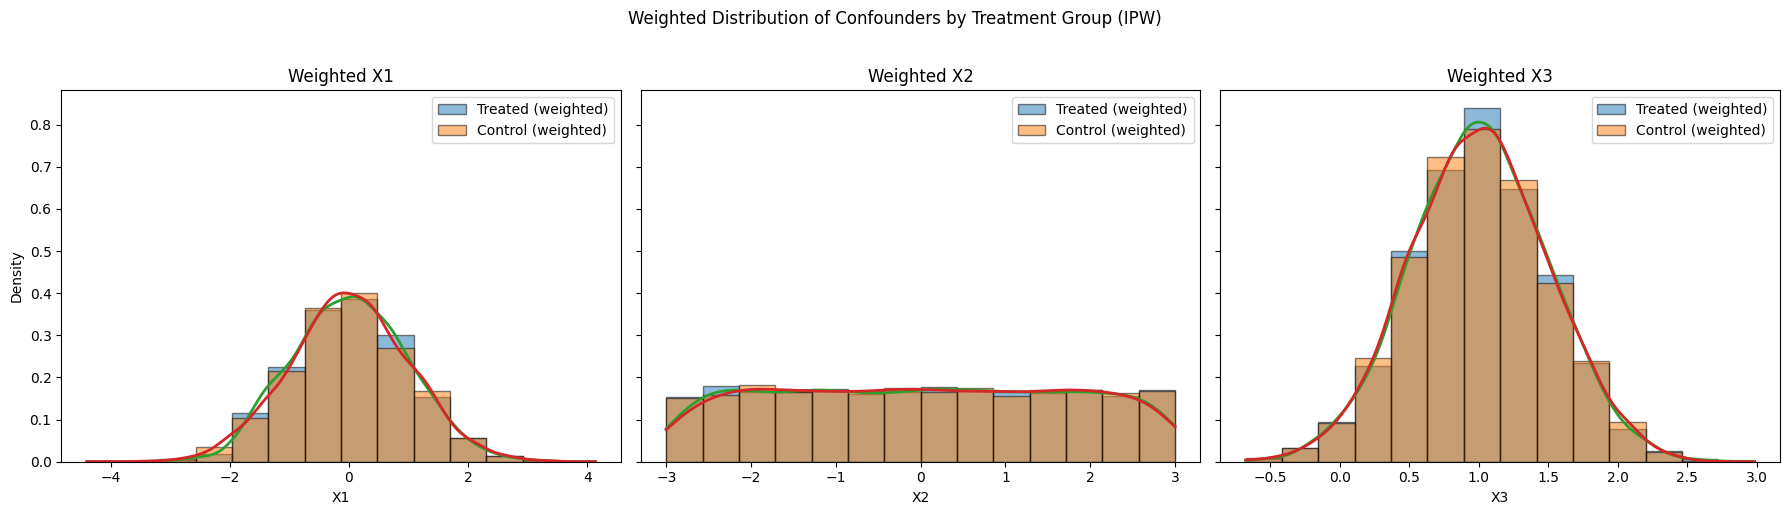

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity


ps = np.asarray(propensity_scores_estimated)
eps = 1e-6


df_synthetic = df_synthetic.copy()
df_synthetic["weight_treated"] = 1.0 / ps
df_synthetic["weight_control"] = 1.0 / (1.0 - ps)


cap = np.quantile(np.r_[df_synthetic["weight_treated"], df_synthetic["weight_control"]], 0.99)
df_synthetic["weight_treated"] = np.minimum(df_synthetic["weight_treated"], cap)
df_synthetic["weight_control"] = np.minimum(df_synthetic["weight_control"], cap)

confounder_cols = ['X1', 'X2', 'X3']


def weighted_kde_curve(x, w, grid, bandwidth=None):
    x = np.asarray(x).reshape(-1, 1)
    w = np.asarray(w).astype(float)


    if bandwidth is None:
        n_eff = (w.sum() ** 2) / (np.square(w).sum() + 1e-12)
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * (n_eff ** (-1/5)) if std > 0 else 1.0

    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(x, sample_weight=w)
    log_dens = kde.score_samples(grid.reshape(-1, 1))
    return np.exp(log_dens)


fig, axes = plt.subplots(1, len(confounder_cols), figsize=(18, 5), sharey=True)

treated = df_synthetic[df_synthetic["T"] == 1]
control = df_synthetic[df_synthetic["T"] == 0]

for i, col in enumerate(confounder_cols):
    x_all = df_synthetic[col].to_numpy()
    bins = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 15)


    axes[i].hist(
        treated[col], bins=bins, weights=treated["weight_treated"],
        density=True, alpha=0.5, label="Treated (weighted)",edgecolor='black',
linewidth=1
    )
    axes[i].hist(
        control[col], bins=bins, weights=control["weight_control"],
        density=True, alpha=0.5, label="Control (weighted)", edgecolor='black',
linewidth=1
    )


    grid = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 300)
    dens_t = weighted_kde_curve(treated[col], treated["weight_treated"], grid)
    dens_c = weighted_kde_curve(control[col], control["weight_control"], grid)
    axes[i].plot(grid, dens_t, linewidth=2)
    axes[i].plot(grid, dens_c, linewidth=2)

    axes[i].set_title(f"Weighted {col}")
    axes[i].set_xlabel(col)
    axes[i].legend()

axes[0].set_ylabel("Density")
plt.suptitle("Weighted Distribution of Confounders by Treatment Group (IPW)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
propensity_scores = df_synthetic['propensity_score']
mse_propensity_scores = np.mean((propensity_scores - propensity_scores_estimated)**2)

print(f"Mean Squared Error of Propensity Scores: {mse_propensity_scores:.4f}")

print(f"\nRange of True Propensity Scores: [{np.min(propensity_scores):.4f}, {np.max(propensity_scores):.4f}]")
print(f"Range of Estimated Propensity Scores: [{np.min(propensity_scores_estimated):.4f}, {np.max(propensity_scores_estimated):.4f}]")

print("\nComparison of True and Estimated Propensity Scores (First 10 units):")
comparison_df = pd.DataFrame({
    'True Propensity Score': propensity_scores[:10],
    'Estimated Propensity Score': propensity_scores_estimated[:10]
})
print(comparison_df)

Mean Squared Error of Propensity Scores: 0.0006

Range of True Propensity Scores: [0.1398, 0.8755]
Range of Estimated Propensity Scores: [0.1405, 0.8749]

Comparison of True and Estimated Propensity Scores (First 10 units):
   True Propensity Score  Estimated Propensity Score
0               0.618650                    0.632691
1               0.364940                    0.372649
2               0.676347                    0.675772
3               0.656108                    0.653543
4               0.487326                    0.465210
5               0.683149                    0.646663
6               0.556990                    0.554323
7               0.640612                    0.598840
8               0.789873                    0.777676
9               0.659219                    0.678339


## Propensity stratification

In [ ]:
def stratification(df, K=5):

    propensity_used = propensity_score_estimation(df)
    df_stratification = df.copy()

    # 1. Divide data into K strata based on propensity scores
    # Handle cases where pd.qcut might create fewer bins due to duplicate edges
    df_stratification['stratum'] = pd.qcut(
        propensity_used,
        q=K,
        labels=False
    )

    stratum_ates = []
    stratum_Ns = [] # Total observations per stratum
    stratum_variance_contributions = []

    N_total = len(df_stratification)

    # Iterate through each unique stratum
    for stratum_id in sorted(df_stratification['stratum'].unique()):
        stratum_df = df_stratification[df_stratification['stratum'] == stratum_id]

        treated_in_stratum = stratum_df[stratum_df['T'] == 1]
        control_in_stratum = stratum_df[stratum_df['T'] == 0]

        N_k = len(stratum_df) # Total observations in current stratum

        if len(treated_in_stratum) > 0 and len(control_in_stratum) > 0:
            # i. Calculate mean outcome for treated and control groups
            mean_outcome_treated = treated_in_stratum['Y'].mean()
            mean_outcome_control = control_in_stratum['Y'].mean()

            # ii. Compute and store stratum-specific ATE
            stratum_ate = mean_outcome_treated - mean_outcome_control
            stratum_ates.append(stratum_ate)

            # iii. Store total number of observations in stratum
            stratum_Ns.append(N_k)

            # iv. Calculate variance of outcomes for treated and control groups
            N_1k = len(treated_in_stratum)
            N_0k = len(control_in_stratum)

            # Handle single observation case for variance (variance = 0 if N <= 1)
            S1k_sq = treated_in_stratum['Y'].var(ddof=1) if N_1k > 1 else 0.0
            S0k_sq = control_in_stratum['Y'].var(ddof=1) if N_0k > 1 else 0.0

            # v. Compute stratum's variance contribution term
            var_contribution_term = 0.0
            if N_1k > 0: # Ensure no division by zero
                var_contribution_term += S1k_sq / N_1k
            if N_0k > 0: # Ensure no division by zero
                var_contribution_term += S0k_sq / N_0k

            # vi. Store this variance contribution term
            stratum_variance_contributions.append(var_contribution_term)
        else:
            # If a stratum has no treated or no control units, it cannot contribute to ATE
            # This case will be handled by np.average ignoring it if stratum_Ns is empty
            pass

    overall_stratified_ate = np.nan
    estimated_variance_stratified_ate = np.nan

    if len(stratum_ates) > 0 and sum(stratum_Ns) > 0:
        # a. Calculate overall stratified ATE as weighted average
        overall_stratified_ate = np.average(stratum_ates, weights=stratum_Ns)

        # b. Calculate the estimated variance of the stratified ATE
        # Using the formula: Var(ATE_strat) = sum_k (N_k/N)^2 * (S1k_sq/N1k + S0k_sq/N0k)
        weighted_variance_sum = 0.0
        for i in range(len(stratum_ates)):
            weight_nk_N = stratum_Ns[i] / N_total
            weighted_variance_sum += (weight_nk_N**2) * stratum_variance_contributions[i]
            weighted_variance_sum += weight_nk_N * (stratum_ates[i] - overall_stratified_ate) ** 2 / N_total
        estimated_variance_stratified_ate = weighted_variance_sum

    return overall_stratified_ate, estimated_variance_stratified_ate


### Run Simulation


In [ ]:
num_simulations = 100

stra_estimates5 = []
stra_var_estimates5 = []
stra_estimates10 = []
stra_var_estimates10 = []
stra_estimates2 = []
stra_var_estimates2 = []

for i in range(num_simulations):
    df = groundtruth_simulate()

    # Simulate and estimate using IPW

    stra_est, var_est = stratification(df,2)
    stra_estimates2.append(stra_est)
    stra_var_estimates2.append(var_est)

    stra_est, var_est = stratification(df,5)
    stra_estimates5.append(stra_est)
    stra_var_estimates5.append(var_est)

    stra_est, var_est = stratification(df,10)
    stra_estimates10.append(stra_est)
    stra_var_estimates10.append(var_est)

print(f"mean of Stratified Estimate (K=2): {np.mean(stra_estimates2):.4f}" )
print(f"Variance of Stratified Estimate (K=2): {np.var(stra_estimates2):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates2):.4f}" )


print(f"mean of Stratified Estimate (K=5): {np.mean(stra_estimates5):.4f}" )
print(f"Variance of Stratified Estimate (K=5): {np.var(stra_estimates5):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates5):.4f}" )

print(f"mean of Stratified Estimate (K=10): {np.mean(stra_estimates10):.4f}" )
print(f"Variance of Stratified Estimate (K=10): {np.var(stra_estimates10):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates10):.4f}" )




mean of Stratified Estimate (K=2): 1.8858
Variance of Stratified Estimate (K=2): 0.0803, expectation of Stratified variance: 0.2523
mean of Stratified Estimate (K=5): 1.9820
Variance of Stratified Estimate (K=5): 0.0801, expectation of Stratified variance: 0.2630
mean of Stratified Estimate (K=10): 2.0171
Variance of Stratified Estimate (K=10): 0.0846, expectation of Stratified variance: 0.2381


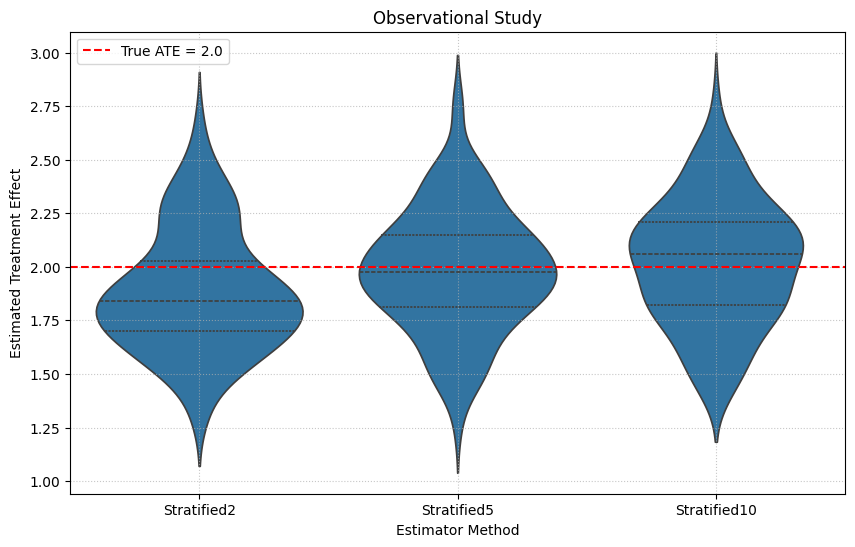

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator':  ['Stratified2'] * len(stra_estimates2) +  ['Stratified5'] * len(stra_estimates5) +  ['Stratified10'] * len(stra_estimates10),
    'Estimate':  stra_estimates2 + stra_estimates5 + stra_estimates10
}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_ate, color='r', linestyle='--', label=f'True ATE = {true_ate}')

# Add labels and title
plt.title('Observational Study')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Propensity-based estimator

### IPW

In [ ]:
## IPW
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.linear_model import LinearRegression # Will be needed later

def IPW(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)
    # Clip ps_estimated between [0.1,0.9]
    #ps_estimated = np.clip(ps_estimated, 0.1, 0.9)


    # 2. Extract treatment (T) and outcome (Y) variables
    T = df['T'].values
    Y = df['Y'].values
    n = len(df)

    ipw_term_treated = (Y * T) / ps_estimated
    ipw_term_control = (Y * (1 - T)) / (1 - ps_estimated)
    ate_ipw = np.mean(ipw_term_treated - ipw_term_control)

    variance_ipw_ate = np.var(ipw_term_treated - ipw_term_control) / (n)

    return ate_ipw, variance_ipw_ate

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.linear_model import LinearRegression # Will be needed later

def Hajek(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)
    # Clip ps_estimated between [0.1,0.9]
    #ps_estimated = np.clip(ps_estimated, 0.1, 0.9)

    # 2. Extract treatment (T) and outcome (Y) variables
    T = df['T'].values
    Y = df['Y'].values
    n = len(df)


    num_treated = np.sum((Y * T) / ps_estimated)
    # Denominator for treated mean (sum of weights for treated)
    den_treated = np.sum(T / ps_estimated)

    # Numerator for control mean
    num_control = np.sum((Y * (1 - T)) / (1 - ps_estimated))
    # Denominator for control mean (sum of weights for control)
    den_control = np.sum((1 - T) / (1 - ps_estimated))

    # Calculate Hajek-weighted means
    mean_treated_hajek = num_treated / den_treated if den_treated > 0 else 0
    mean_control_hajek = num_control / den_control if den_control > 0 else 0

    # Calculate Hajek ATE
    ate_hajek = mean_treated_hajek - mean_control_hajek


    individual_term_treated = (Y * T) / ps_estimated
    individual_term_control = (Y * (1 - T)) / (1 - ps_estimated)


    variance_hajek_ate = np.var(individual_term_treated - individual_term_control) / n

    return ate_hajek, variance_hajek_ate

### Outcome Regression

In [ ]:
#Outcome regression
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def outcome_reg(df):
    # 1. Extract confounder variables and the outcome variable
    X_confounders = df[['X1', 'X2', 'X3']]
    n = len(df)

    # Separate data into treated and control groups
    treated_df = df[df['T'] == 1]
    control_df = df[df['T'] == 0]
    n1 = len(treated_df)
    n0 = len(control_df) # Get number of control units

    # 2. Fit a LinearRegression model for the treated group
    model_treated = LinearRegression()
    model_treated.fit(treated_df[['X1', 'X2', 'X3']], treated_df['Y'])

    # 3. Fit a LinearRegression model for the control group
    model_control = LinearRegression()
    model_control.fit(control_df[['X1', 'X2', 'X3']], control_df['Y'])

    # 4. Predict the potential outcomes for each unit (using ALL confounders)
    # mu_1_hat (predicted outcome if treated, T=1)
    predicted_outcome_treated = model_treated.predict(X_confounders)

    # mu_0_hat (predicted outcome if control, T=0)
    predicted_outcome_control = model_control.predict(X_confounders)

    # 5. Calculate the ATE
    ate_or = np.mean(predicted_outcome_treated - predicted_outcome_control)

    # 6. Compute the variance of the outcome regression ATE
    # find residuals
    # Calculate residuals manually as sklearn LinearRegression does not have a .resid attribute
    residualsT = treated_df['Y'] - model_treated.predict(treated_df[['X1', 'X2', 'X3']])
    residualsC = control_df['Y'] - model_control.predict(control_df[['X1', 'X2', 'X3']])

    # Ensure there are enough samples to calculate variance (at least 2 for ddof=1)
    var_residualsT = np.var(residualsT, ddof=1) if n1 > 1 else 0.0
    var_residualsC = np.var(residualsC, ddof=1) if n0 > 1 else 0.0

    # Variance components based on the original structure


    variance_component_models = var_residualsT / n1
    variance_component_models += var_residualsC / n0


    variance_or_ate = variance_component_models + np.var(predicted_outcome_treated - predicted_outcome_control, ddof=1) / n

    return ate_or, variance_or_ate

### AIPW

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression # Ensure both are imported


def AIPW(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)

    # 2. Extract treatment (T), outcome (Y), and confounder variables
    X_confounders = df[['X1', 'X2', 'X3']]
    Y = df['Y'].values
    T = df['T'].values
    n = len(df)

    treated_df = df[df['T'] == 1]
    control_df = df[df['T'] == 0]
    model_treated = LinearRegression()
    model_treated.fit(treated_df[['X1', 'X2', 'X3']], treated_df['Y'])
    model_control = LinearRegression()
    model_control.fit(control_df[['X1', 'X2', 'X3']], control_df['Y'])


    mu_1_hat = model_treated.predict(X_confounders)
    mu_0_hat = model_control.predict(X_confounders)


    # 5. Calculate the individual components of the efficient influence function (EIF) for the AIPW estimator
    # EIF_i = mu_1_hat[i] - mu_0_hat[i] + (T[i] * (Y[i] - mu_1_hat[i])) / ps_estimated[i] - ((1 - T[i]) * (Y[i] - mu_0_hat[i])) / (1 - ps_estimated[i])
    eif_term_y1_minus_y0 = mu_1_hat - mu_0_hat
    eif_term_treated_correction = (T * (Y - mu_1_hat)) / ps_estimated
    eif_term_control_correction = ((1 - T) * (Y - mu_0_hat)) / (1 - ps_estimated)

    eif = eif_term_y1_minus_y0 + eif_term_treated_correction - eif_term_control_correction

    # 6. The AIPW estimate of the ATE (ate_aipw) is the mean of these EIF_i values.
    ate_aipw = np.mean(eif)

    # 7. The variance of the AIPW estimate (variance_aipw_ate) is the variance of the EIF_i values divided by the number of samples n.
    variance_aipw_ate = np.var(eif, ddof=1) / n

    return ate_aipw, variance_aipw_ate

## Run Simulation




In [ ]:
num_simulations = 100

ipw_estimates = []
ipw_var_estimates = []
or_estimates = []
or_var_estimates = []
aipw_estimates = []
aipw_var_estimates = []
hajek_estimates = []
hajek_var_estimates = []

for i in range(num_simulations):
    df = groundtruth_simulate()

    # IPW Estimator
    ate_ipw, var_ipw = IPW(df)
    ipw_estimates.append(ate_ipw)
    ipw_var_estimates.append(var_ipw)

    # Outcome Regression Estimator
    ate_or, var_or = outcome_reg(df)
    or_estimates.append(ate_or)
    or_var_estimates.append(var_or)

    # AIPW Estimator
    ate_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(ate_aipw)
    aipw_var_estimates.append(var_aipw)

    # Hajek Estimator
    ate_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(ate_hajek)
    hajek_var_estimates.append(var_hajek)

print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW ATE Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW ATE Estimates: {np.var(ipw_estimates):.4f}")
print(f"Mean of Estimated IPW Variances: {np.mean(ipw_var_estimates):.4f}")

print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR ATE Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR ATE Estimates: {np.var(or_estimates):.4f}")
print(f"Mean of Estimated OR Variances: {np.mean(or_var_estimates):.4f}")

print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW ATE Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW ATE Estimates: {np.var(aipw_estimates):.4f}")
print(f"Mean of Estimated AIPW Variances: {np.mean(aipw_var_estimates):.4f}")

print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek ATE Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek ATE Estimates: {np.var(hajek_estimates):.4f}")
print(f"Mean of Estimated Hajek Variances: {np.mean(hajek_var_estimates):.4f}")

--- IPW Estimator Results (n_simulations=100) ---
Mean of IPW ATE Estimates: 1.9589
Empirical Variance of IPW ATE Estimates: 0.0602
Mean of Estimated IPW Variances: 0.4060

--- Outcome Regression Estimator Results (n_simulations=100) ---
Mean of OR ATE Estimates: 1.9875
Empirical Variance of OR ATE Estimates: 0.0458
Mean of Estimated OR Variances: 0.0383

--- AIPW Estimator Results (n_simulations=100) ---
Mean of AIPW ATE Estimates: 1.9865
Empirical Variance of AIPW ATE Estimates: 0.0464
Mean of Estimated AIPW Variances: 0.0416

--- Hajek Estimator Results (n_simulations=100) ---
Mean of Hajek ATE Estimates: 1.9723
Empirical Variance of Hajek ATE Estimates: 0.0573
Mean of Estimated Hajek Variances: 0.4060


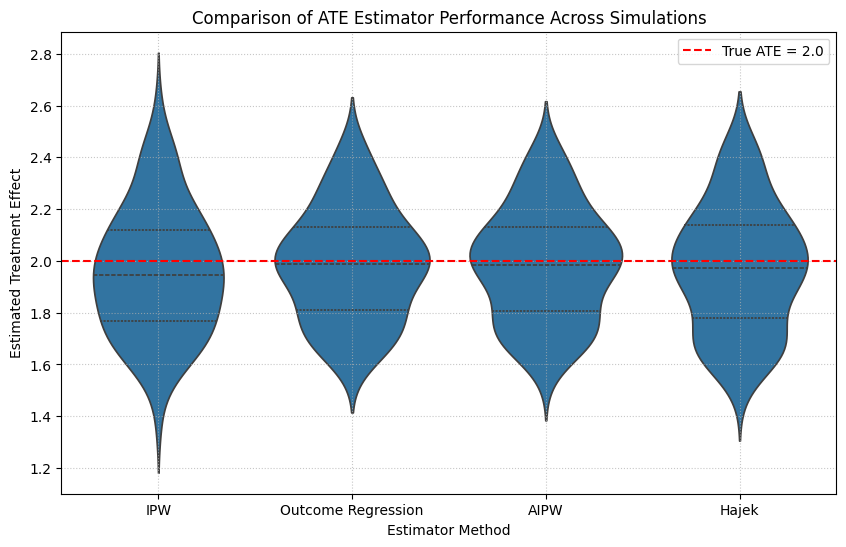

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator':  ['IPW'] * len(ipw_estimates) +
                  ['Outcome Regression'] * len(or_estimates) +
                  ['AIPW'] * len(aipw_estimates) +
                  ['Hajek'] * len(hajek_estimates),
    'Estimate':  ipw_estimates + or_estimates + aipw_estimates + hajek_estimates
}
df_plot = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df_plot, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_ate, color='r', linestyle='--', label=f'True ATE = {true_ate}')

# Add labels and title
plt.title('Comparison of ATE Estimator Performance Across Simulations')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Model Mispecification

In [ ]:
n_samples = 100
true_ate = 2.0
from scipy.stats import norm
# 2. Generate confounders
np.random.seed(412) # for reproducibility
def groundtruth_simulate_mis(propensity = True, outcome = True):
  X1 = np.random.normal(loc=0, scale=1, size=n_samples)
  X2 = np.random.uniform(low=-3, high=3, size=n_samples)
  X3 = np.random.normal(loc=1, scale=0.5, size=n_samples)
  X4 = X1 ** 2 + X2 ** 2
  # 3. Define the treatment assignment mechanism (propensity score)

  propensity_score_logit = 0.5 * X1 - 0.3 * X2 + 0.2 * X3
  if propensity == False: propensity_score_logit -= 0.3 * X4
  propensity_scores = expit(propensity_score_logit)

  # Generate binary treatment assignments (T)
  T = np.random.binomial(n=1, p=propensity_scores, size=n_samples)

  # 4. Define the outcome generation mechanism
  # Outcome Y depends on confounders, treatment T, and noise
  # The coefficient for T is the true_ate

  ####### !!!! add intersection term
  Y = 1 + 0.8 * X1 + 1.2 * X2 - 0.5 * X3  + true_ate * T +  np.random.normal(loc=0, scale=1, size=n_samples)
  if outcome ==False: Y += X4
  # 5. Combine into a Pandas DataFrame
  df_synthetic = pd.DataFrame({
      'X1': X1,
      'X2': X2,
      'X3': X3,
      'T': T,
      'Y': Y,
      'propensity_score': propensity_scores # Include for inspection if needed
  })
  return df_synthetic


In [ ]:
num_simulations = 1000

ipw_estimates = []
ipw_var_estimates = []
or_estimates = []
or_var_estimates = []
aipw_estimates = []
aipw_var_estimates = []
hajek_estimates = []
hajek_var_estimates = []

for i in range(num_simulations):
    df = groundtruth_simulate_mis(False, True)

    # IPW Estimator
    ate_ipw, var_ipw = IPW(df)
    ipw_estimates.append(ate_ipw)
    ipw_var_estimates.append(var_ipw)

    # Outcome Regression Estimator
    ate_or, var_or = outcome_reg(df)
    or_estimates.append(ate_or)
    or_var_estimates.append(var_or)

    # AIPW Estimator
    ate_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(ate_aipw)
    aipw_var_estimates.append(var_aipw)

    # Hajek Estimator
    ate_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(ate_hajek)
    hajek_var_estimates.append(var_hajek)

print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW ATE Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW ATE Estimates: {np.var(ipw_estimates):.4f}")
print(f"Mean of Estimated IPW Variances: {np.mean(ipw_var_estimates):.4f}")

print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR ATE Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR ATE Estimates: {np.var(or_estimates):.4f}")
print(f"Mean of Estimated OR Variances: {np.mean(or_var_estimates):.4f}")

print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW ATE Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW ATE Estimates: {np.var(aipw_estimates):.4f}")
print(f"Mean of Estimated AIPW Variances: {np.mean(aipw_var_estimates):.4f}")

print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek ATE Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek ATE Estimates: {np.var(hajek_estimates):.4f}")
print(f"Mean of Estimated Hajek Variances: {np.mean(hajek_var_estimates):.4f}")

--- IPW Estimator Results (n_simulations=1000) ---
Mean of IPW ATE Estimates: 1.7072
Empirical Variance of IPW ATE Estimates: 0.0750
Mean of Estimated IPW Variances: 0.3975

--- Outcome Regression Estimator Results (n_simulations=1000) ---
Mean of OR ATE Estimates: 1.9926
Empirical Variance of OR ATE Estimates: 0.0512
Mean of Estimated OR Variances: 0.0448

--- AIPW Estimator Results (n_simulations=1000) ---
Mean of AIPW ATE Estimates: 1.9941
Empirical Variance of AIPW ATE Estimates: 0.0517
Mean of Estimated AIPW Variances: 0.0438

--- Hajek Estimator Results (n_simulations=1000) ---
Mean of Hajek ATE Estimates: 1.8694
Empirical Variance of Hajek ATE Estimates: 0.0652
Mean of Estimated Hajek Variances: 0.3975


In [ ]:
num_simulations = 1000

ipw_estimates = []
ipw_var_estimates = []
or_estimates = []
or_var_estimates = []
aipw_estimates = []
aipw_var_estimates = []
hajek_estimates = []
hajek_var_estimates = []

for i in range(num_simulations):
    df = groundtruth_simulate_mis(True, False)

    # IPW Estimator
    ate_ipw, var_ipw = IPW(df)
    ipw_estimates.append(ate_ipw)
    ipw_var_estimates.append(var_ipw)

    # Outcome Regression Estimator
    ate_or, var_or = outcome_reg(df)
    or_estimates.append(ate_or)
    or_var_estimates.append(var_or)

    # AIPW Estimator
    ate_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(ate_aipw)
    aipw_var_estimates.append(var_aipw)

    # Hajek Estimator
    ate_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(ate_hajek)
    hajek_var_estimates.append(var_hajek)

print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW ATE Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW ATE Estimates: {np.var(ipw_estimates):.4f}")
print(f"Mean of Estimated IPW Variances: {np.mean(ipw_var_estimates):.4f}")

print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR ATE Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR ATE Estimates: {np.var(or_estimates):.4f}")
print(f"Mean of Estimated OR Variances: {np.mean(or_var_estimates):.4f}")

print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW ATE Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW ATE Estimates: {np.var(aipw_estimates):.4f}")
print(f"Mean of Estimated AIPW Variances: {np.mean(aipw_var_estimates):.4f}")

print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek ATE Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek ATE Estimates: {np.var(hajek_estimates):.4f}")
print(f"Mean of Estimated Hajek Variances: {np.mean(hajek_var_estimates):.4f}")

--- IPW Estimator Results (n_simulations=1000) ---
Mean of IPW ATE Estimates: 1.9921
Empirical Variance of IPW ATE Estimates: 0.8309
Mean of Estimated IPW Variances: 2.3110

--- Outcome Regression Estimator Results (n_simulations=1000) ---
Mean of OR ATE Estimates: 2.0481
Empirical Variance of OR ATE Estimates: 0.5470
Mean of Estimated OR Variances: 0.4058

--- AIPW Estimator Results (n_simulations=1000) ---
Mean of AIPW ATE Estimates: 2.0137
Empirical Variance of AIPW ATE Estimates: 0.7177
Mean of Estimated AIPW Variances: 0.6112

--- Hajek Estimator Results (n_simulations=1000) ---
Mean of Hajek ATE Estimates: 1.9831
Empirical Variance of Hajek ATE Estimates: 0.5536
Mean of Estimated Hajek Variances: 2.3110


In [ ]:
num_simulations = 1000

ipw_estimates = []
ipw_var_estimates = []
or_estimates = []
or_var_estimates = []
aipw_estimates = []
aipw_var_estimates = []
hajek_estimates = []
hajek_var_estimates = []

for i in range(num_simulations):
    df = groundtruth_simulate_mis(False, False)

    # IPW Estimator
    ate_ipw, var_ipw = IPW(df)
    ipw_estimates.append(ate_ipw)
    ipw_var_estimates.append(var_ipw)

    # Outcome Regression Estimator
    ate_or, var_or = outcome_reg(df)
    or_estimates.append(ate_or)
    or_var_estimates.append(var_or)

    # AIPW Estimator
    ate_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(ate_aipw)
    aipw_var_estimates.append(var_aipw)

    # Hajek Estimator
    ate_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(ate_hajek)
    hajek_var_estimates.append(var_hajek)

print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW ATE Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW ATE Estimates: {np.var(ipw_estimates):.4f}")
print(f"Mean of Estimated IPW Variances: {np.mean(ipw_var_estimates):.4f}")

print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR ATE Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR ATE Estimates: {np.var(or_estimates):.4f}")
print(f"Mean of Estimated OR Variances: {np.mean(or_var_estimates):.4f}")

print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW ATE Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW ATE Estimates: {np.var(aipw_estimates):.4f}")
print(f"Mean of Estimated AIPW Variances: {np.mean(aipw_var_estimates):.4f}")

print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek ATE Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek ATE Estimates: {np.var(hajek_estimates):.4f}")
print(f"Mean of Estimated Hajek Variances: {np.mean(hajek_var_estimates):.4f}")

--- IPW Estimator Results (n_simulations=1000) ---
Mean of IPW ATE Estimates: -0.7315
Empirical Variance of IPW ATE Estimates: 0.5237
Mean of Estimated IPW Variances: 1.7394

--- Outcome Regression Estimator Results (n_simulations=1000) ---
Mean of OR ATE Estimates: -0.3705
Empirical Variance of OR ATE Estimates: 0.4559
Mean of Estimated OR Variances: 0.3412

--- AIPW Estimator Results (n_simulations=1000) ---
Mean of AIPW ATE Estimates: -0.3999
Empirical Variance of AIPW ATE Estimates: 0.5018
Mean of Estimated AIPW Variances: 0.3784

--- Hajek Estimator Results (n_simulations=1000) ---
Mean of Hajek ATE Estimates: -0.3104
Empirical Variance of Hajek ATE Estimates: 0.4288
Mean of Estimated Hajek Variances: 1.7394


# Bootstrap

In [ ]:
def bootstrap(method, df, num_resamples):
    ate_estimates = []
    for _ in range(num_resamples):
        # Create a bootstrap sample (resample with replacement)
        bootstrap_sample = df.sample(n=len(df), replace=True, random_state=None) # random_state=None for different samples each time

        # Apply the provided method to the bootstrap sample
        # Assuming the method returns (ate_estimate, variance_estimate)
        ate_estimate, _ = method(bootstrap_sample)
        ate_estimates.append(ate_estimate)

    # Convert to numpy array for easier calculations
    ate_estimates = np.array(ate_estimates)

    # Calculate empirical variance
    empirical_variance = np.var(ate_estimates, ddof=1) # ddof=1 for sample variance

    # Calculate 2.5% and 97.5% quantiles
    lower_quantile = np.percentile(ate_estimates, 2.5)
    upper_quantile = np.percentile(ate_estimates, 97.5)

    return empirical_variance, lower_quantile, upper_quantile


In [ ]:
num_simulations = 100

ipw_estimates = []
or_estimates = []
aipw_estimates = []
hajek_estimates = []

# New lists for bootstrap results
ipw_bootstrap_vars = []
or_bootstrap_vars = []
aipw_bootstrap_vars = []
hajek_bootstrap_vars = []

ipw_err = 0
or_err = 0
aipw_err = 0
hajek_err = 0

for i in range(num_simulations):
    # Change data generation call
    df = groundtruth_simulate()

    # IPW Estimator
    ate_ipw, var_ipw = IPW(df)
    ipw_estimates.append(ate_ipw)
    # Bootstrap for IPW
    bs_var_ipw, bs_lower_ipw, bs_upper_ipw = bootstrap(IPW, df, num_resamples=100)
    ipw_bootstrap_vars.append(bs_var_ipw)
    ipw_err += (true_ate < bs_lower_ipw) or (true_ate > bs_upper_ipw)


    # Outcome Regression Estimator
    ate_or, var_or = outcome_reg(df)
    or_estimates.append(ate_or)
    or_var_estimates.append(var_or)
    # Bootstrap for OR
    bs_var_or, bs_lower_or, bs_upper_or = bootstrap(outcome_reg, df, num_resamples=100)
    or_bootstrap_vars.append(bs_var_or)
    or_err += (true_ate < bs_lower_or) or (true_ate > bs_upper_or)


    # AIPW Estimator
    ate_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(ate_aipw)
    aipw_var_estimates.append(var_aipw)
    # Bootstrap for AIPW
    bs_var_aipw, bs_lower_aipw, bs_upper_aipw = bootstrap(AIPW, df, num_resamples=100)
    aipw_bootstrap_vars.append(bs_var_aipw)
    aipw_err += (true_ate < bs_lower_aipw) or (true_ate > bs_upper_aipw)


    # Hajek Estimator
    ate_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(ate_hajek)
    hajek_var_estimates.append(var_hajek)
    # Bootstrap for Hajek
    bs_var_hajek, bs_lower_hajek, bs_upper_hajek = bootstrap(Hajek, df, num_resamples=100)
    hajek_bootstrap_vars.append(bs_var_hajek)
    hajek_err += (true_ate < bs_lower_hajek) or (true_ate > bs_upper_hajek)

print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW ATE Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW ATE Estimates: {np.var(ipw_estimates):.4f}")
print(f"Mean of IPW Bootstrap Variances: {np.mean(ipw_bootstrap_vars):.4f}")


print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR ATE Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR ATE Estimates: {np.var(or_estimates):.4f}")
print(f"Mean of OR Bootstrap Variances: {np.mean(or_bootstrap_vars):.4f}")

print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW ATE Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW ATE Estimates: {np.var(aipw_estimates):.4f}")
print(f"Mean of AIPW Bootstrap Variances: {np.mean(aipw_bootstrap_vars):.4f}")

print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek ATE Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek ATE Estimates: {np.var(hajek_estimates):.4f}")
print(f"Mean of Hajek Bootstrap Variances: {np.mean(hajek_bootstrap_vars):.4f}")

print("Type-I errors:",ipw_err/num_simulations, or_err/num_simulations, aipw_err/num_simulations, hajek_err/num_simulations)


--- IPW Estimator Results (n_simulations=100) ---
Mean of IPW ATE Estimates: 2.0086
Empirical Variance of IPW ATE Estimates: 0.0475
Mean of IPW Bootstrap Variances: 0.0691

--- Outcome Regression Estimator Results (n_simulations=100) ---
Mean of OR ATE Estimates: 2.0421
Empirical Variance of OR ATE Estimates: 0.0396
Mean of OR Bootstrap Variances: 0.0481

--- AIPW Estimator Results (n_simulations=100) ---
Mean of AIPW ATE Estimates: 2.0418
Empirical Variance of AIPW ATE Estimates: 0.0402
Mean of AIPW Bootstrap Variances: 0.0505

--- Hajek Estimator Results (n_simulations=100) ---
Mean of Hajek ATE Estimates: 2.0274
Empirical Variance of Hajek ATE Estimates: 0.0445
Mean of Hajek Bootstrap Variances: 0.0620
Type-I errors: 0.07 0.08 0.06 0.06
